# What do attention heads actually attend to?

**Companion to Talk 1, slide "What do heads actually attend to?"**

We train a 2-layer, 4-head transformer on a toy task, then look inside. By the end you will have:

- eight attention heatmaps, one per head,
- a quantitative "fingerprint" naming what each head does,
- an **ablation** showing which heads the model cannot survive without.

Total runtime ~40 s on a laptop CPU. No GPU, no downloads, no dataset files.

The heads are not told what to do. They specialise on their own, and two of the roles they
discover — the **previous-token head** and the **induction head** — are exactly the ones found
in real language models.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import math, time, random, statistics
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0); random.seed(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device, "| torch", torch.__version__)

device: cuda | torch 2.10.0


---
## The toy dataset: a sequence that repeats itself

Take a random block of tokens and tile it until the sequence is full:

```
period T = 5
 3  9 12  0  8 | 3  9 12  0  8 | 3  9 12  0  8 | ...
```

The model is trained to predict the next token. In the first block that is impossible — the tokens
are random. From the second block onward there is exactly one strategy that works:

> *"I am looking at token 12. Where did 12 appear before? What came after it that time? Say that."*

That is **induction**, and it is a content-based lookup: it cannot be done by position or by recency.

**The one detail that matters:** the period $T$ is **resampled every batch**. If $T$ were fixed, the
model would learn the trivial shortcut "copy from exactly $T$ positions back" — a purely positional
rule — and no interesting heads would form. (Worth trying: fix `T` and watch every head collapse to
the same offset.) Randomising $T$ closes that door and forces content matching.

In [2]:
NTOK, VOCAB = 16, 16
L = 32                       # total sequence length
TMIN, TMAX = 5, 13           # period range

def make_batch(B, T=None):
    T = T or random.randint(TMIN, TMAX)
    a = torch.randint(0, NTOK, (B, T))
    seq = a.repeat(1, (L // T) + 2)[:, :L + 1]
    return seq[:, :-1].to(device), seq[:, 1:].to(device), T

x, y, T = make_batch(1, T=5)
print("period:", T)
print("input :", x[0].tolist())
print("target:", y[0].tolist())

period: 5
input : [12, 15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15]
target: [15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15, 5, 0, 3, 12, 15, 5]


---
## The model, with attention written out by hand

We implement multi-head attention explicitly rather than calling `nn.MultiheadAttention`, for two
reasons: it mirrors the equations on the slides, and it lets us (a) keep every head's attention
matrix and (b) switch individual heads **off** for the ablation.

In [3]:
class MHA(nn.Module):
    def __init__(self, d, nh):
        super().__init__()
        self.nh, self.dh = nh, d // nh
        self.qkv = nn.Linear(d, 3 * d, bias=False)
        self.o   = nn.Linear(d, d, bias=False)
        self.attn = None                      # saved for inspection
    def forward(self, x, head_mask=None):
        B, Lx, d = x.shape
        q, k, v = self.qkv(x).chunk(3, -1)
        q, k, v = [t.view(B, Lx, self.nh, self.dh).transpose(1, 2) for t in (q, k, v)]
        s = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)          # scaled dot product
        causal = torch.triu(torch.ones(Lx, Lx, device=x.device, dtype=torch.bool), 1)
        s = s.masked_fill(causal, float("-inf"))                    # no peeking ahead
        a = s.softmax(-1)
        self.attn = a.detach()
        y = a @ v
        if head_mask is not None:                                   # ablation hook
            y = y * head_mask.view(1, self.nh, 1, 1).to(y.device)
        return self.o(y.transpose(1, 2).reshape(B, Lx, d))

class Block(nn.Module):
    def __init__(self, d, nh, ff):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.att = MHA(d, nh)
        self.ff  = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Linear(ff, d))
    def forward(self, x, hm=None):
        x = x + self.att(self.n1(x), hm)
        return x + self.ff(self.n2(x))

class Tiny(nn.Module):
    def __init__(self, d=64, nh=4, nl=2, ff=256, maxlen=64):
        super().__init__()
        self.emb, self.pos = nn.Embedding(VOCAB, d), nn.Embedding(maxlen, d)
        self.blocks = nn.ModuleList([Block(d, nh, ff) for _ in range(nl)])
        self.nf, self.head = nn.LayerNorm(d), nn.Linear(d, VOCAB)
        self.nh, self.nl = nh, nl
    def forward(self, x, masks=None):
        h = self.emb(x) + self.pos(torch.arange(x.shape[1], device=x.device))[None]
        for i, b in enumerate(self.blocks):
            h = b(h, None if masks is None else masks[i])
        return self.head(self.nf(h))

model = Tiny().to(device)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters, "
      f"{model.nl} layers x {model.nh} heads")

105,744 parameters, 2 layers x 4 heads


---
## Train it

Watch the accuracy: it sits near chance while the model has no idea, then rises sharply once the
two-layer circuit assembles. That jump is the induction head forming.

final induction accuracy: 0.984  (11s, 1075 steps)


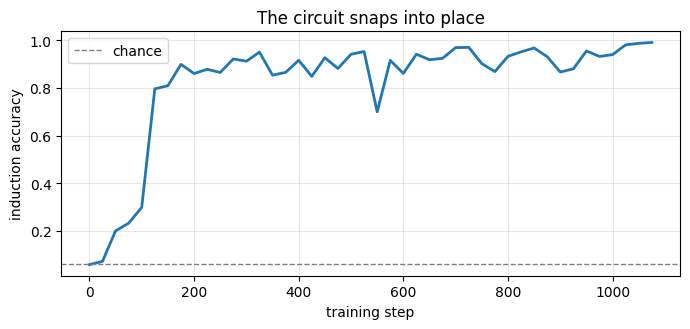

In [4]:
def induction_acc(m, n=512, T=None, masks=None):
    m.eval()
    with torch.no_grad():
        xx, yy, Tt = make_batch(n, T)
        pred = m(xx, masks).argmax(-1)
        reg = slice(Tt, L)                    # only where induction is possible
        a = (pred[:, reg] == yy[:, reg]).float().mean().item()
    m.train(); return a

opt = torch.optim.Adam(model.parameters(), lr=3e-3)
sch = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min(1.0, (s + 1) / 100))
hist, t0 = [], time.time()
for s in range(4000):
    xx, yy, _ = make_batch(64)
    loss = F.cross_entropy(model(xx).reshape(-1, VOCAB), yy.reshape(-1))
    opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sch.step()
    if s % 25 == 0: hist.append((s, induction_acc(model, 256)))
    if s > 300 and hist[-1][1] > 0.99: break
print(f"final induction accuracy: {induction_acc(model, 2048):.3f}  ({time.time()-t0:.0f}s, {s} steps)")

plt.figure(figsize=(7, 3.4))
plt.plot(*zip(*hist), lw=2)
plt.axhline(1 / NTOK, ls="--", c="gray", lw=1, label="chance")
plt.xlabel("training step"); plt.ylabel("induction accuracy")
plt.title("The circuit snaps into place"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
# The main event: eight heads, eight pictures

Each panel is one head's attention matrix for a single sequence. Row $i$ is the query at position
$i$; the bright cells are the positions it read from. Everything above the diagonal is black —
that is the causal mask.

Two patterns to look for:

- a bright line **one step below the diagonal** → a **previous-token head**
- a bright line **$T{-}1$ steps below the diagonal** → an **induction head** (it is reaching back
  to just after the last occurrence of the current token)

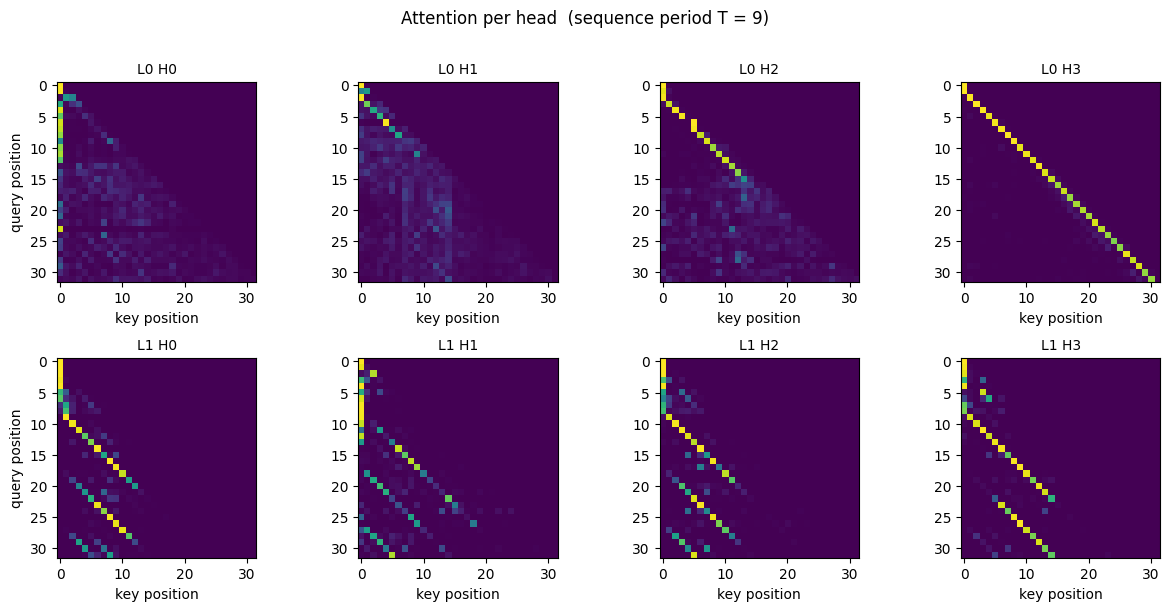

sequence: [14, 5, 3, 13, 4, 7, 13, 12, 6, 14, 5, 3, 13, 4, 7, 13, 12, 6, 14, 5, 3, 13, 4, 7, 13, 12, 6, 14, 5, 3, 13, 4]


In [5]:
PERIOD = 9                                  # try 5, 7, 11 as well
model.eval()
with torch.no_grad():
    xp, yp, _ = make_batch(1, T=PERIOD)
    model(xp)

fig, axes = plt.subplots(model.nl, model.nh, figsize=(3.1 * model.nh, 3.0 * model.nl))
for li, b in enumerate(model.blocks):
    A = b.att.attn[0].cpu().numpy()
    for hi in range(model.nh):
        ax = axes[li][hi]
        ax.imshow(A[hi], cmap="viridis", vmin=0, vmax=1)
        ax.set_title(f"L{li} H{hi}", fontsize=10)
        ax.set_xlabel("key position");
        if hi == 0: ax.set_ylabel("query position")
plt.suptitle(f"Attention per head  (sequence period T = {PERIOD})", y=1.01)
plt.tight_layout(); plt.show()
print("sequence:", xp[0].tolist())

---
## Naming the heads, quantitatively

Eyeballing heatmaps is how people fool themselves. So we score every head: for each query in the
region where induction is possible, find the position it attends to most, and check which rule that
matches.

In [6]:
rows = list(range(PERIOD + 2, L))
print(f"{'head':7s} {'prev-token':>11s} {'induction':>10s} {'sink(pos 0)':>12s} {'median offset':>14s}")
fingerprints = {}
for li, b in enumerate(model.blocks):
    A = b.att.attn[0]
    for hi in range(model.nh):
        a = A[hi]
        tgt = [int(a[i].argmax()) for i in rows]
        off = [t - i for t, i in zip(tgt, rows)]
        prev = np.mean([o == -1 for o in off])
        ind  = np.mean([o == -(PERIOD - 1) for o in off])
        sink = np.mean([t == 0 for t in tgt])
        fingerprints[f"L{li}H{hi}"] = (prev, ind, sink)
        print(f"L{li}H{hi:<4d} {prev:11.2f} {ind:10.2f} {sink:12.2f} {statistics.median(off):+14.0f}")

print("\ninterpretation:")
for k, (prev, ind, sink) in fingerprints.items():
    label = ("previous-token head" if prev > 0.5 else
             "induction head"      if ind  > 0.3 else
             "attention sink"      if sink > 0.3 else "mixed / unclear")
    print(f"  {k}: {label}")

head     prev-token  induction  sink(pos 0)  median offset
L0H0           0.00       0.05         0.52            -17
L0H1           0.00       0.10         0.05            -11
L0H2           0.00       0.00         0.14             -5
L0H3           1.00       0.00         0.00             -1
L1H0           0.00       0.48         0.00            -17
L1H1           0.00       0.33         0.10            -17
L1H2           0.00       0.38         0.00            -17
L1H3           0.00       0.57         0.00             -8

interpretation:
  L0H0: attention sink
  L0H1: mixed / unclear
  L0H2: mixed / unclear
  L0H3: previous-token head
  L1H0: induction head
  L1H1: induction head
  L1H2: induction head
  L1H3: induction head


### What we see

**Which head index gets which job depends on the random seed**.

Reliably, across seeds: **exactly one head in layer 0** becomes a near-perfect previous-token head,
one or two park on position 0, and **most of layer 1** does induction.

**Layer 0 discovers "what came just before me". Layer 1 uses that to match and copy.** That is a
two-step algorithm, split across two layers, that nobody specified.

This is exactly the induction circuit from the interpretability literature, and it is the same
mechanism behind in-context learning in real LLMs.

Note also the **attention sink**: a head that dumps its weight on position 0 when it has nothing
useful to do. Softmax must sum to 1, so a head that wants to be "off" needs somewhere to park its
attention. Real LLMs do this too.